# Creating a HazardTimeSeries from a Hazard object

In this tutorial, we explain how one can sample a number of time series from a Hazard object. 

In [1]:
# import packages
import numpy as np
import pandas as pd

from climada.hazard import Hazard
from climada.test import get_test_file
from climada.hazard.timeseries import HazardTimeSeries

In [2]:
# load example hazard object: Historic tropical cyclones in Florida from 1990 to 2004
haz_tc_fl = Hazard.from_hdf5(get_test_file("HAZ_DEMO_FL_15"))

2025-09-23 17:57:30,746 - climada.hazard.io - INFO - Reading /Users/vgebhart/climada/data/hazard/template/HAZ_DEMO_FL_15/v1/HAZ_DEMO_FL_15.h5


To sample from the hazard object, we have to define for which timesteps we want to sample. The timesteps should be a list/array consisting of ordinal dates each of which corresponds to the start of the timestep. Note that the timesteps will be treated as equidistant event though do not have to be (as in the monthly timesteps example below).

In [3]:
timesteps_months = pd.date_range(
    "2025-01-01",
    "2029-12-31",
    freq="MS",
)
print(
    f"Here we defined {len(timesteps_months)} timesteps (months) from {timesteps_months[0].strftime('%d %b %Y')} to {timesteps_months[-1].strftime('%d %b %Y')}."
)
timesteps_months = [
    date.toordinal() for date in timesteps_months
]  # convert to ordinal dates

Here we defined 60 timesteps (months) from 01 Jan 2025 to 01 Dec 2029.


Using the optional `seasonality` parameter, we can include some seasonality in the timesteps. The seasonality should be an array of the same shape as the timesteps. The frequency of the Hazard per timestep will be modulated (i.e., multiplied) by the seasonality parameter for every timestep.
(TBD: add normalization option?)

In [4]:
# example seasonality: TCs only in summer months (Jun-Oct) in Florda, Apr and Nov transition months
seasonality_per_month = [0, 0, 0, 0, 1, 2, 2, 2, 2, 2, 1, 0]
seasonality = np.array(seasonality_per_month * 5)

Now, we sample 50 time series for the given timesteps and seasonality.

In [5]:
# sample a number of timeseries
n_timeseries = 50
haz_timeseries = HazardTimeSeries.sample_from_hazard_set(
    haz_tc_fl, n_timeseries, timesteps_months, seasonality=seasonality, seed=None
)
haz_timeseries.check_time_series()

To illustrate the resulting time series, we plot the dates of the sampled events (in x direction) for each time series (y direction).

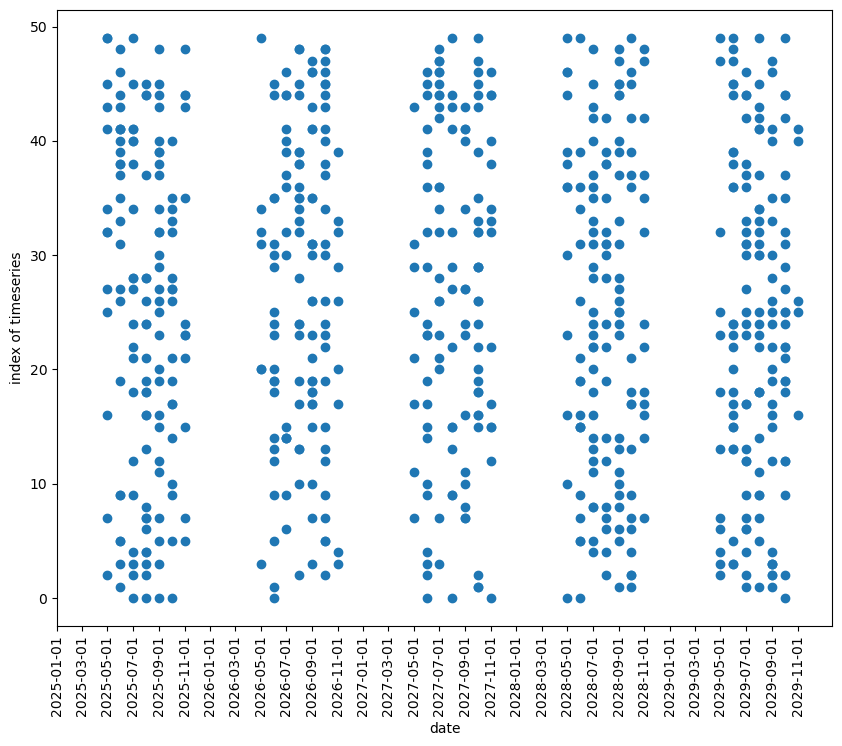

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
plt.xticks(rotation=90)
ax.scatter(haz_timeseries.date, haz_timeseries.id_timeseries)
ax.set_ylabel("index of timeseries")
ax.set_xlabel("date")

ticks = pd.date_range(
    "2025-01-01",
    "2029-12-31",
    freq="2MS",
)
ticks_ord = [date.toordinal() for date in ticks]
ax.set_xticks(ticks_ord)
ax.set_xticklabels(ticks.astype(str));

If the mean of seasonality is 1, the frequency of events in the timeseries should approach the frequency of events according to the original probabilistic event set.

In [19]:
print(
    np.round(sum(haz_timeseries.frequency), 2),
    haz_timeseries.frequency_unit,
    "frequency of all events in timeseries object",
)
print(
    np.round(sum(haz_tc_fl.frequency), 2),
    haz_timeseries.frequency_unit,
    "frequency of probabilitc event set object",
)

20.84 1/year frequency of all events in timeseries object
14.4 1/year frequency of probabilitc event set object


## Include changes in frequency and intensity to time series sampling

For long time series, one might want to include changes in frequency and intensity in the sampling. These changes can be included via the optional `seasonality` and `intensity_change` parameters:
- *Changes in frequency*. Changes in the mean event frequency per timestep can be included in by adapting the `seasonality` parameter that also includes seasonality. The modulations due to seasonality and frequency change are thus combine in this single parameter.
- *Changes in intensity*. Changes in intensity per timestep can be included by the `intensity_change` parameter, that must have the same shape as timesteps. For a given timestep, the sampled event's intensities are then simply multiplied by the corresponding value in `intensity_change`. 

In [14]:
# frequency increases by a factor of 0.2 per year
seasonality_per_month = [0, 0, 0, 0, 1, 2, 2, 2, 2, 2, 1, 0]
increase_per_year = np.array([np.ones(12) * 1.2**i for i in range(5)]).flatten()

seasonality = np.array(seasonality_per_month * 5) * increase_per_year

# intensity increases by 0.1 per year
intensity_change = np.array([np.ones(12) * 1.1**i for i in range(5)]).flatten()

In [15]:
# sample a number of timeseries
n_timeseries = 50
haz_timeseries = HazardTimeSeries.sample_from_hazard_set(
    haz_tc_fl,
    n_timeseries,
    timesteps_months,
    seasonality=seasonality,
    intensity_change=intensity_change,
    seed=None,
)
haz_timeseries.check_time_series()

Since the frequencies are increasing, the event date per time series plot is now denser for future periods. Similarly, the intesity would -- on average -- increase in the future (not shown in the plot).

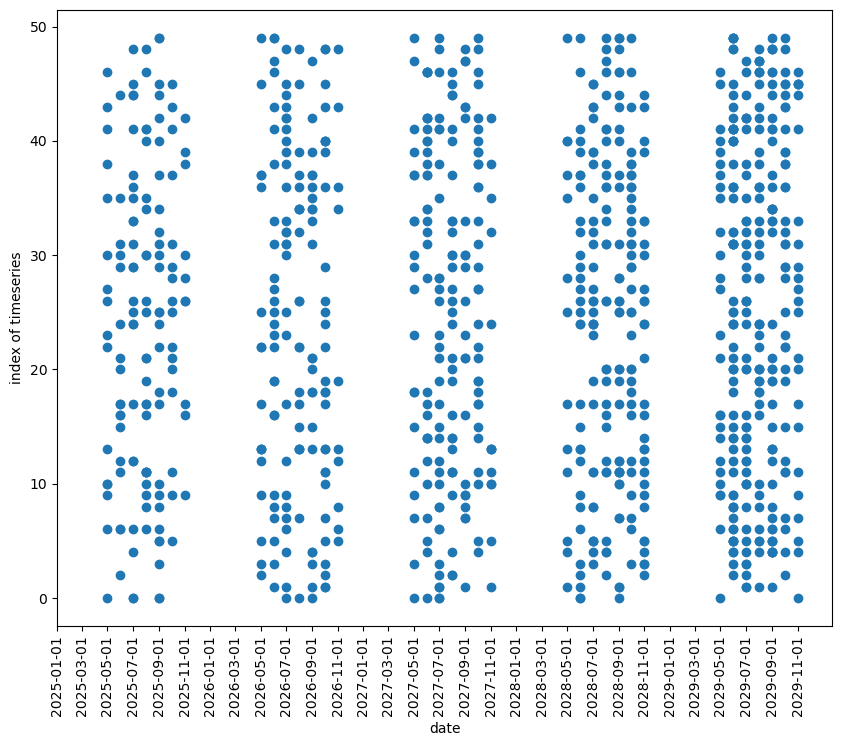

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
plt.xticks(rotation=90)
ax.scatter(haz_timeseries.date, haz_timeseries.id_timeseries)
ax.set_ylabel("index of timeseries")
ax.set_xlabel("date")

ticks = pd.date_range(
    "2025-01-01",
    "2029-12-31",
    freq="2MS",
)
ticks_ord = [date.toordinal() for date in ticks]
ax.set_xticks(ticks_ord)
ax.set_xticklabels(ticks.astype(str));

Different to above, since we made the frequencies increase with respect to the original hazard object, the mean of seasonality is not 1 anymore. Thus, the average frequency over the whole timeseries object will most probably be higher that the frequency of the original event set

In [18]:
print(
    np.round(sum(haz_timeseries.frequency), 2),
    haz_timeseries.frequency_unit,
    "frequency of all events in timeseries object",
)
print(
    np.round(sum(haz_tc_fl.frequency), 2),
    haz_timeseries.frequency_unit,
    "frequency of probabilitc event set object",
)

20.84 1/year frequency of all events in timeseries object
14.4 1/year frequency of probabilitc event set object
